# Tensorflow 

In [6]:
import tensorflow as tf
import numpy as np

- Parallelization
- Tensors --> anything can be a tensor --> A multi dimensional array
- We just convert into a tensor and use them  


In [4]:
tf.__version__

'2.20.0'

In [5]:
tf.config.list_physical_devices('GPU')

[]

In [8]:
tf.config.list_physical_devices('GPU')

[]

- We are converting it into tensor to take advantage of faster GPU

In [9]:
!nvidia-smi

- Tokenization:

    - Split text into words
    - assign a random number to every word
    - eg. I love Pizza -->  [5,7,9]

- top N most frequent words -> MAX_WORDS
- rare words -> OOV

- Sequencing
    - we need to store 5,7,9  in that order, 5,9,7 --> doesn't work i.e we need to save the sequence also.
- Padding and Truncating

    - Padding: 
        - Some sentences might be short and some might be long
        - Padding and truncating is used to make all sentences of same length 
        - Padding increases the size of the input and truncating decreases the size of the input


- Embedding:

    - 


In [14]:
x = tf.constant([[1.0,2.0],[3.0,4.0]])
x

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 2.],
       [3., 4.]], dtype=float32)>

In [2]:
# Install required packages (if needed)
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


In [3]:
layers.Embedding(input_dim = 10000, output_dim = 128, input_length = 200)

# input_dim --> number of unique words/ vocabulary size
# output_dim --> no. of features we are selecting to represent a single word 
# input length --> using padding and truncating, we are liiting the length of every sentence to 200 

<Embedding name=embedding, built=False>

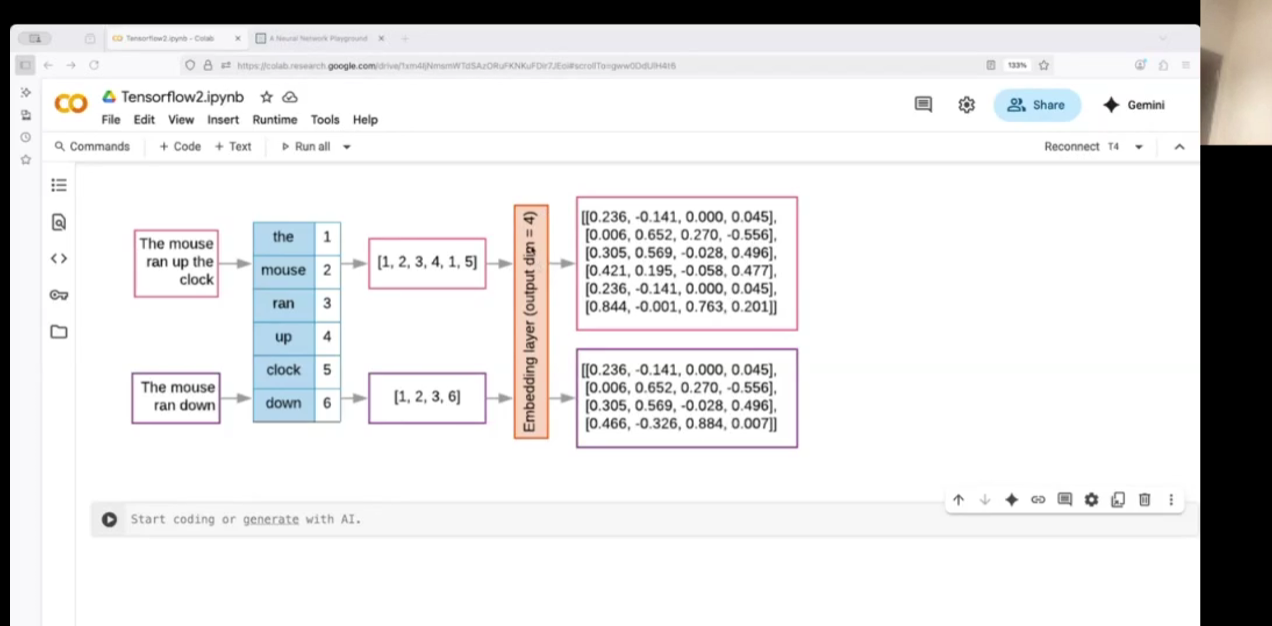

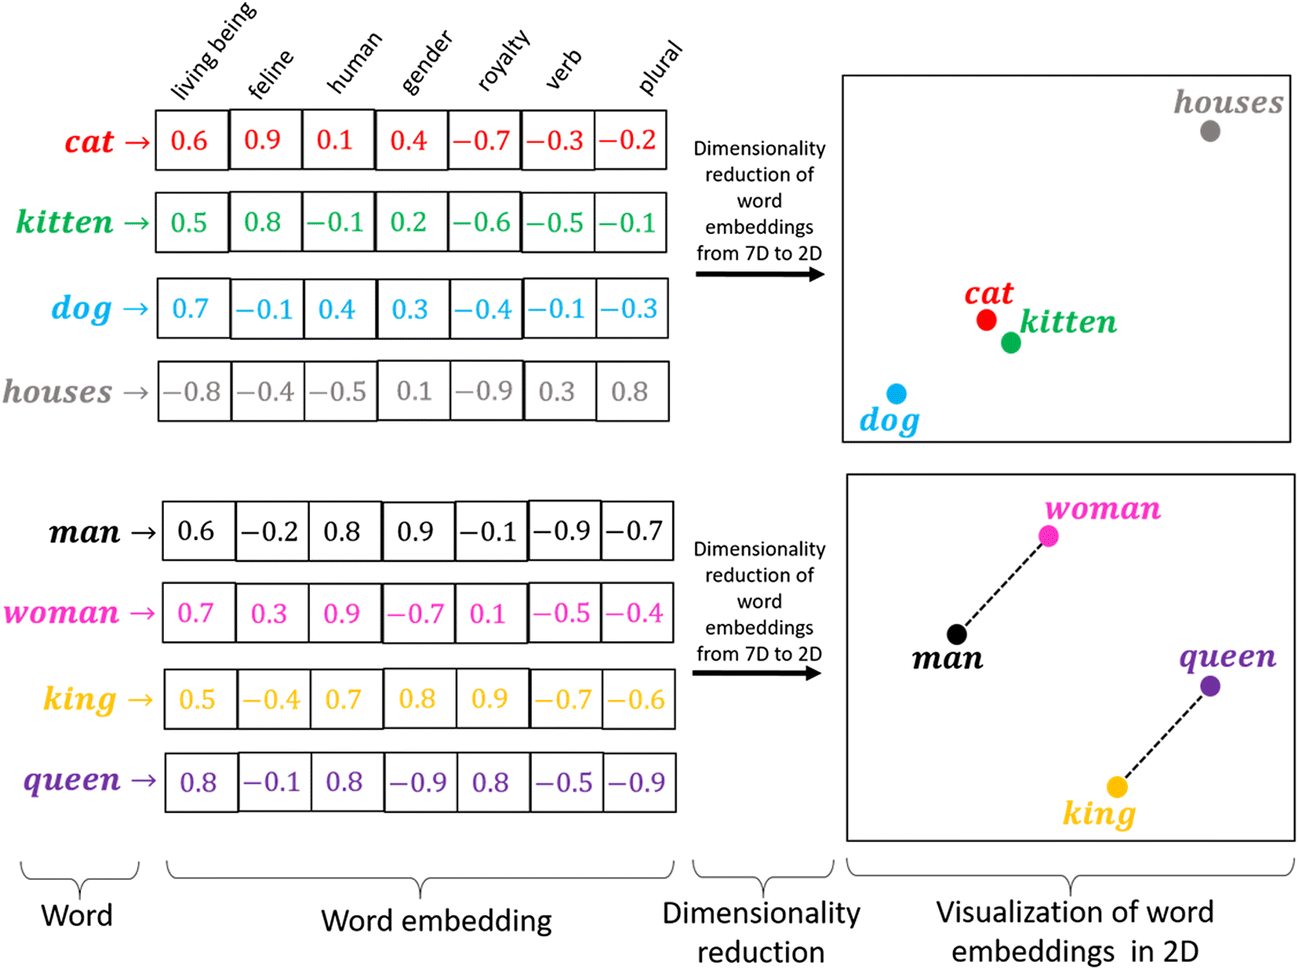

In [4]:
df = pd.read_csv('ai_human_content_detection_dataset.csv')

df.head()

,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

sentences = ["AI is amazing", "Humans are creative", "I am Iron Man"]
tokenizer = Tokenizer(num_words=10, oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

print(tokenizer.word_index)

{'<OOV>': 1, 'ai': 2, 'is': 3, 'amazing': 4, 'humans': 5, 'are': 6, 'creative': 7, 'i': 8, 'am': 9, 'iron': 10, 'man': 11}


In [7]:
test_sentences = ["I am Bat Man", "I love Robots"]

print(tokenizer.texts_to_sequences(test_sentences))

[[8, 9, 1, 1], [8, 1, 1]]
